<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/04_02_%ED%99%95%EB%A5%A0%EC%A0%81%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95%EB%B2%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MBC 마켓은 럭키백의 성공으로 인하여 각각의 지역에 수산물을 제공하기로 하였다.

# 영업팀은 매주 생선을 무작위로 골라, 머신러닝 모델을 학습할 수 있도록 훈련 데이터를 제공하고 있다.
# 하지만, 수산물을 제공하는 곳이 너무 많아서 샘플을 골라내는 일이 어려워졌고, 추가되는 수산물의 샘플도 존재하지 않게 되었다.
# 영업팀은 새로운 종류의 생선이 도착하는 즉시 훈련 데이터를 제공해야 한다.

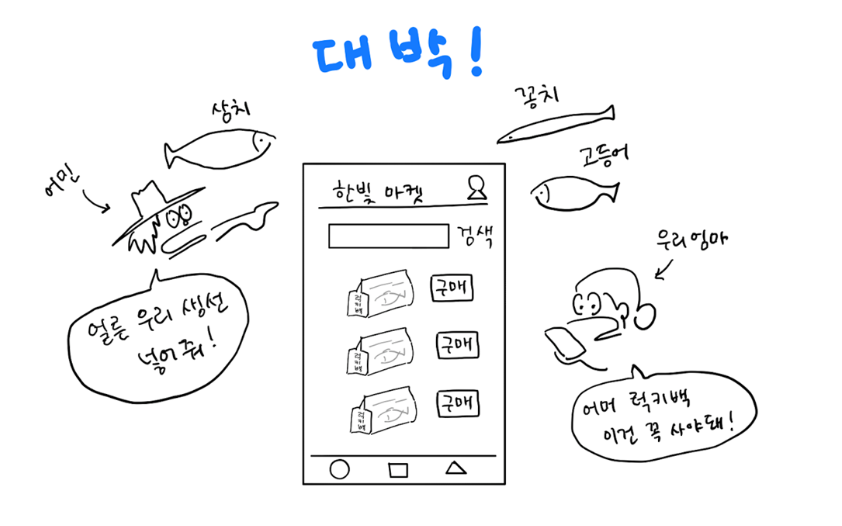

In [ ]:
# 점진적 학습

# 당면한 문제 : 훈련 데이터가 한번에 준비되지 않고 조금씩 전달된다.
# 해결 방안 1 : 기존의 훈련 데이터에 새로운 데이터를 추가하여 모델을 매일매일 다시 훈련시킨다.
#            → 시간이 지날수록 데이터가 누적되기 때문에, 인력 추가, 서버 증설, 시간적 여유 등에 어려움이 생긴다. (한계점)

# 해결 방안 2 : 새로운 데이터를 추가할 때마다 이전 데이터를 제거한다.
#            → 훈련 데이터 크기를 일정하게 유지할 수 있다.
#            → 그러나 데이터를 제거할 때 다른 데이터에는 없는 중요한 데이터가 포함되어 있다면? (한계점)

# 해결 방안 3 : 점진적 학습 방법
#            → 온라인 학습으로서, 훈련한 모델을 제거하지 않고 조금씩 새로운 데이터를 학습시킨다. (확률적 경사 하강법)

In [ ]:
# 확률적 경사 하강법 : 훈련 세트에서 무작위로 하나의 샘플을 선택한 후, 가파른 경사를 조금씩 내려간다. (실제 산에서 내려오는 것처럼, 가파른 길을 찾아 천천히 조금씩 내려온다.) → 이를 반복적으로 수행한다.
# 모든 샘플을 다 사용했는데도 다 내려오지 못했다면 처음부터 다시 시작한다.
# 에포크(epoch) : 훈련 세트를 모두 한번 사용하는 과정

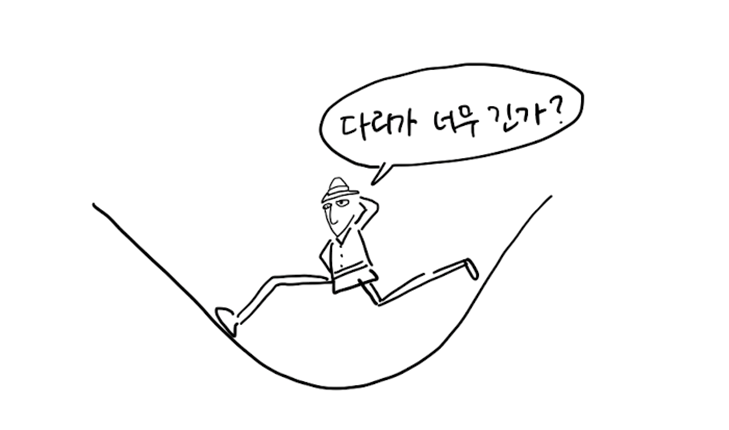

In [ ]:
# 훈련 방법 : 가장 가파른 길을 찾아서 내려오되, 조금씩 내려와야 한다.
# 훈련 세트를 활용하여 모델을 훈련하기 때문에, 경사 하강법 또한 당연하게 가장 가파른 길을 찾아야 한다.

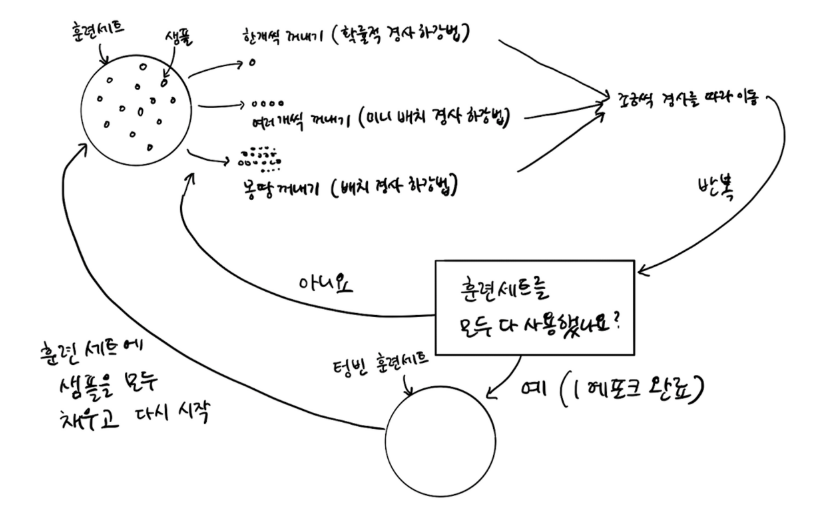

In [ ]:
# 위의 방법대로 샘플을 1개만 활용하면 너무 무책임하게 내려갈 수도 있다. → 잘못된 훈련으로 도출된 결과는 돌이킬 수 없다.
# 이러한 문제점을 해소시키고자, 무작위로 다수의 샘플을 활용하여 경사를 내려가는 방법도 존재한다.
# 미니 배치 경사하강법 : 여러 개의 샘플을 활용하여 경사 하강을 진행한다.
# 배치 경사하강법 : 극단적으로 전체 샘플을 활용하여 경사를 따라 이동한다.
# 단점 : 컴퓨터 자원을 지나치게 사용하게 되고, 전체 데이터를 한번에 모두 읽을 수 없다.
# 롹률적 경사 하강법은 훈련 세트를 활용하여 최적의 장소로 조금씩 이동하기 때문에, 훈련 데이터가 모두 준비되어 있지 않고 매일 업데이트 해도 학습을 이어나갈 수 있다. → 신경망 알고리즘

# 손실 함수(Loss function) : 머신러닝 알고리즘이 얼마나 엉터리인지 측정하는 기준 (작을수록 좋다.)
# 하지만 어떤 값이 최소값이 알지 못하기 때문에, 가능한 많이 찾아보고 만족할만한 수준이라면 인정해야 한다.
# 손실 함수 공식 : Loss = - log(p) → p = 모델이 '1'이라고 예측한 확률

# 비용 함수(Cost function) : 훈련 세트에 있는 모든 샘플에 대한 손실 함수의 합 (손실 함수의 다른 표현)

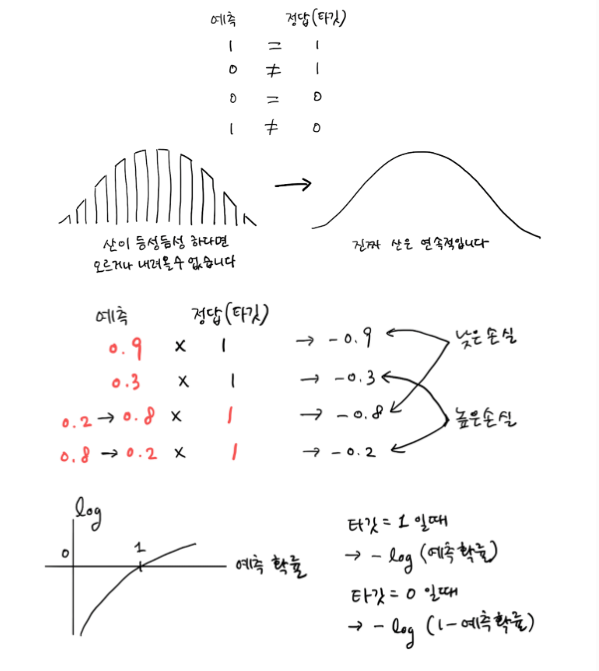

In [ ]:
# 정답이 1인 경우
# 모델이 높은 확률(0.9, 0.8)로 맞춘다면 손실이 작다.
# 모델이 낮은 확률(0.3, 0.2)로 맞춘다면 손실이 크다.

# 로그 값은 '0 ~ 1' 사이에서 항상 음수이기 때문에, 손실은 앞에 마이너스를 붙여서 양수로 바꾼다.
# log(0.9) ≈ - 0.1
# log(0.2) ≈ - 1.6

In [1]:
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head() # 'fish'에 있는 리스트 中 상위 5개의 데이터를 출력한다.

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
fish_input = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy() # Species(어류)를 제외한 나머지 필드를 'fish_input' 변수에 리스트로 넣는다.
fish_target = fish['Species'].to_numpy() # Species(어류)를 정답 파일로 생성한다.
print(fish_target)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish'
 'Whitefish' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki'
 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'

In [4]:
from sklearn.model_selection import train_test_split

import numpy as np
np.set_printoptions(precision = 6, suppress = True) # 하단의 '표준 점수 변환용'에서 활용한다.
#                   precision = 6 : 소수점 6자리까지 출력한다.
#                                  suppress = True : 과학적 표기법(지수 표기)을 사용하지 않는다.

# 사이킷런을 활용하여 훈련 자료와 테스트 자료를 나눈다.
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)
print('train_input')
print(train_input)
# 결과 : 요소 119, 특성 5

train_input
[[ 720.       35.       40.6      16.3618    6.09  ]
 [ 500.       45.       48.        6.96      4.896 ]
 [   7.5      10.5      11.6       1.972     1.16  ]
 [ 110.       22.       23.5       5.5225    3.995 ]
 [ 140.       20.7      23.2       8.5376    3.2944]
 [  69.       18.2      20.3       5.2983    2.8217]
 [ 110.       21.       22.5       5.6925    3.555 ]
 [ 620.       34.5      39.7      15.5227    5.2801]
 [ 130.       21.3      22.8       6.384     3.534 ]
 [  85.       20.       21.        5.082     2.772 ]
 [ 685.       36.5      39.       10.881     6.864 ]
 [ 500.       31.       36.2      14.3714    4.8146]
 [ 514.       32.8      34.       10.03      6.018 ]
 [ 200.       23.       25.8      10.3458    3.6636]
 [1000.       44.       46.6      12.4888    7.5958]
 [ 714.       36.       41.5      16.517     5.8515]
 [   8.7      11.3      12.6       1.9782    1.2852]
 [1000.       43.       45.2      11.9328    7.2772]
 [ 110.       20.8      23.1      

In [5]:
print(train_input.shape)
# 결과 : 요소 119, 특성 5

(119, 5)


In [6]:
print('test_input')
print(test_input)

test_input
[[  78.       18.7      19.4       5.1992    3.1234]
 [  13.4      12.4      13.5       2.43      1.269 ]
 [ 200.       32.3      34.8       5.568     3.3756]
 [ 270.       26.       28.7       8.3804    4.2476]
 [ 150.       23.       24.5       5.2185    3.626 ]
 [1000.       37.       42.6      18.957     6.603 ]
 [   7.       10.6      11.6       1.7284    1.1484]
 [ 180.       25.2      27.9       7.0866    3.906 ]
 [ 188.       24.6      26.2       6.7334    4.1658]
 [1250.       56.       59.7      10.6863    6.9849]
 [ 650.       33.5      38.7      14.4738    5.7276]
 [1000.       40.       43.5      12.354     6.525 ]
 [ 600.       32.       37.2      15.438     5.58  ]
 [ 150.       20.       22.4       8.8928    3.2928]
 [ 700.       35.       40.5      16.2405    5.589 ]
 [ 920.       38.5      44.1      18.0369    6.3063]
 [1000.       43.5      46.       12.604     8.142 ]
 [ 218.       26.5      28.        7.168     4.144 ]
 [ 225.       24.       25.5       

In [7]:
print(test_input.shape)
# 결과 : 요소 40, 특성 5

(40, 5)


In [10]:
# 훈련용 : 요소 119, 특성 5
# 테스트용 : 요소 40, 특성 5

# 정답 리스트를 확인해보자.
print('train_target : ' + train_target) # 훈련 정답 : 119개

['train_target : Bream' 'train_target : Pike' 'train_target : Smelt'
 'train_target : Perch' 'train_target : Parkki' 'train_target : Roach'
 'train_target : Perch' 'train_target : Bream' 'train_target : Perch'
 'train_target : Perch' 'train_target : Perch' 'train_target : Bream'
 'train_target : Perch' 'train_target : Parkki' 'train_target : Perch'
 'train_target : Bream' 'train_target : Smelt' 'train_target : Perch'
 'train_target : Roach' 'train_target : Bream' 'train_target : Pike'
 'train_target : Bream' 'train_target : Pike' 'train_target : Perch'
 'train_target : Parkki' 'train_target : Bream' 'train_target : Perch'
 'train_target : Pike' 'train_target : Bream' 'train_target : Perch'
 'train_target : Parkki' 'train_target : Roach' 'train_target : Perch'
 'train_target : Bream' 'train_target : Roach' 'train_target : Perch'
 'train_target : Bream' 'train_target : Bream' 'train_target : Perch'
 'train_target : Perch' 'train_target : Roach' 'train_target : Pike'
 'train_target : Perc

In [11]:
print(test_target) # 테스트 정답 : 40개

['Perch' 'Smelt' 'Pike' 'Whitefish' 'Perch' 'Bream' 'Smelt' 'Roach'
 'Perch' 'Pike' 'Bream' 'Whitefish' 'Bream' 'Parkki' 'Bream' 'Bream'
 'Perch' 'Perch' 'Perch' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream'
 'Perch' 'Perch' 'Whitefish' 'Smelt' 'Smelt' 'Pike' 'Perch' 'Perch' 'Pike'
 'Bream' 'Perch' 'Roach' 'Roach' 'Parkki' 'Perch']


In [12]:
from sklearn.preprocessing import StandardScaler # 훈련 세트와 테스트 세트의 특성을 표준화 전처리 한다. (표준 점수로 처리한다.)

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
print(train_scaled[:5])

[[ 0.919658  0.609432  0.810412  1.851949  1.000757]
 [ 0.300412  1.546534  1.453166 -0.469817  0.272917]
 [-1.085854 -1.68647  -1.708486 -1.701598 -2.004476]
 [-0.797341 -0.608802 -0.674869 -0.824806 -0.276315]
 [-0.712899 -0.730625 -0.700927 -0.08023  -0.703387]]


In [13]:
print(test_scaled[:5])

[[-0.887414 -0.918046 -1.030989 -0.904645 -0.807625]
 [-1.069247 -1.50842  -1.543455 -1.588496 -1.938032]
 [-0.544014  0.356414  0.306633 -0.81357  -0.653889]
 [-0.346981 -0.233961 -0.223205 -0.11905  -0.122335]
 [-0.684751 -0.515091 -0.588011 -0.899878 -0.50125 ]]


In [14]:
from sklearn.linear_model import SGDClassifier # SGDClassifier : 사이킷런의 확률적 경사 하강법을 제공하고, 2개의 매개변수를 지정한다.

sc = SGDClassifier(loss = 'log_loss', max_iter = 10, random_state = 42)
# loss = 'log_loss' : 로지스틱 손실 함수를 지정한다.
# max_iter = 10 : 에포크를 10회 반복한다. (== 훈련 세트를 전체 10회 반복한다.)

sc.fit(train_scaled, train_target) # 훈련을 시작한다.

print(sc.score(train_scaled, train_target)) # 약 77.31%
print(sc.score(test_scaled, test_target)) # 약 77.5%

# 결과 : 반복 횟수의 부족으로, 'max_iter'를 향상시킨 후 다시 훈련한다.

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [15]:
# 'SGDClassifier' 객체를 또 만들지 않고, 훈련할 모델을 'sc'로 추가적으로 생성하여 훈련을 진행한다.
sc.partial_fit(train_scaled, train_target) # .partial_fit : 부분적으로 학습한다.

print(sc.score(train_scaled, train_target)) # 약 79.83%
print(sc.score(test_scaled, test_target)) # 약 77.5%

# 결과 : 정확도가 향상되고 있다.
# 퍼센트가 증가할 때 무작정 부분적인 학습을 진행하는 것은 의미가 없기 때문에, 기준점을 제공해야 한다.

0.7983193277310925
0.775


In [ ]:
# 에포크와 과대 혹은 과소 적합
# 확률적 경사 하강법을 사용한 모델은 에포크 횟수에 따라 과소 혹은 과대 적합이 될 수 있다.
# 에포크 횟수가 적다면 훈련 세트를 덜 학습한다. (e.g. 119개에서 10번만 무작위로 추출하고 정지한다.)
# 에포크 횟수가 충분히 많다면 훈련 세트를 완전히 학습할 것이다.

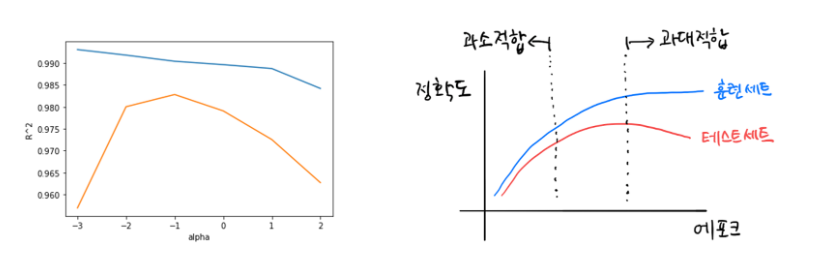

In [ ]:
# 다시 말해, 에포크 횟수가 적을 때 훈련된 모델은 훈련 세트와 테스트 세트에 적합하지 않다. (과소 적합)
# 반대로, 에포크 횟수가 많을 때 훈련된 모델의 경우 너무 적합하기 때문에 오히려 테스트 세트의 점수가 나쁘게 도출된다. (과대 적합)
# 조기 종료 : 과대 적합이 되기 전에 훈련을 중단시킨다.

In [17]:
import numpy as np

sc =  SGDClassifier(loss = 'log_loss', random_state = 42)

train_score = [] # 훈련 세트 점수를 누적하는 빈 리스트
test_score = [] # 테스트 세트 점수를 누적하는 빈 리스트

# 'train_target'에 존재하는 7종의 생선 목록을 제공한다.
classes =  np.unique(train_target)

# 파이썬의 '_' 변수 (1회용)
for _ in range(0, 300) : # 300번의 에포크동안 훈련을 진행한다.
  sc.partial_fit(train_scaled, train_target, classes = classes)

  # 반복할 때마다 훈련 세트와 테스트 세트의 점수를 계산한 후, 'train_score'와 'test_score'의 리스트에 추가한다.
  train_score.append(sc.score(train_scaled, train_target)) # 훈련 세트의 점수를 빈 리스트에 추가한다.
  test_score.append(sc.score(test_scaled, test_target)) # 테스트 세트의 점수를 빈 리스트에 추가한다.

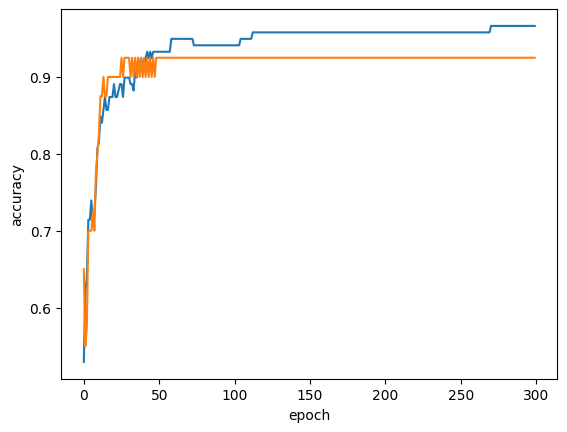

In [18]:
import matplotlib.pyplot as plt

plt.plot(train_score) # 훈련 세트 점수
plt.plot(test_score) # 테스트 세트 점수
plt.xlabel('epoch') # 에포크 횟수
plt.ylabel('accuracy') # 정확도
plt.show()

# 결과 : 에포크 횟수를 100번 정도 돌리니, 차트상으로 과소 혹은 과대 적합이 아니다. (최상의 결과)

In [19]:
sc = SGDClassifier(loss = 'log_loss', max_iter = 100, tol = None, random_state = 42)
#                                                     tol = None : 조기종료 안 한다.
# 성능이 향상되지 않는다면 더이상 훈련하지 않고 자동으로 멈춘다.

sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target)) # 약 95.79%
print(sc.score(test_scaled, test_target)) # 약 92.5%

# 결과 : 최적의 상태

0.957983193277311
0.925


In [20]:
sc.predict(test_scaled[:5]) # Perch Smelt Pike Perch Perch

proba = sc.predict_proba(test_scaled[:5])
np.round(proba, decimals = 3)

array([[0.   , 0.003, 0.774, 0.   , 0.219, 0.   , 0.005],
       [0.   , 0.001, 0.015, 0.   , 0.04 , 0.945, 0.   ],
       [0.   , 0.   , 0.011, 0.96 , 0.02 , 0.008, 0.001],
       [0.   , 0.   , 0.525, 0.   , 0.423, 0.   , 0.052],
       [0.   , 0.   , 0.688, 0.   , 0.306, 0.   , 0.006]])

In [21]:
sc.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype='<U9')

In [ ]:
# 손실 함수에 대한 'loss' 매개변수

# 'loss' 매개 값의 기본값 : loss = hinge (힌지 손실) → 서포트 백터 머신(SVM)이라고도 불린다.
# SVM : 두 클래스를 가장 멀리 떨어지게 나누는 경계를 찾는 알고리즘
# 즉, 두 클래스 사이의 간격(마진)이 가장 넓은 선을 선택한다.

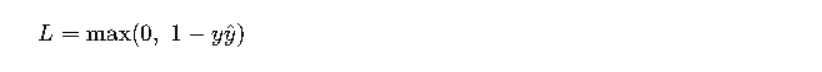

In [22]:
# 힌지 손실은 단순히 맞추는 게 아니라, 결정 경계에서 충분히 멀리 떨어져서 맞추길 원한다. → 가장 안전하게 나누는 선을 찾는 알고리즘이다.

sc_hinge = SGDClassifier(loss = 'hinge', max_iter = 100, tol = None, random_state = 42)
sc_hinge.fit(train_scaled, train_target)

print(sc_hinge.score(train_scaled, train_target))
print(sc_hinge.score(test_scaled, test_target))

0.9495798319327731
0.925


In [23]:
sc_hinge.predict(test_scaled[:5]) # Perch Smelt Pike Perch Perch
# 단, 힌지 손실 함수는 'predict_proba()'를 지원하지 않는다.

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype='<U9')

In [24]:
sc_hinge.partial_fit(train_scaled, train_target)
print(sc_hinge.score(train_scaled, train_target))
print(sc_hinge.score(test_scaled, test_target))

0.907563025210084
0.925


In [25]:
from sklearn.metrics import hinge_loss

train_score = []
test_score = []
train_loss = []
test_loss = []

clsses = np.unique(train_target)

sc_hinge_test = SGDClassifier(loss = 'hinge', max_iter = 1, tol = None, random_state = 42)

for _ in range(300) :
  sc_hinge_test.partial_fit(train_scaled, train_target, classes = classes)

  # accuracy
  train_score.append(sc_hinge_test.score(train_scaled, train_target))
  test_score.append(sc_hinge_test.score(test_scaled, test_target))

  # loss
  train_decision = sc_hinge_test.decision_function(train_scaled)
  test_decision = sc_hinge_test.decision_function(test_scaled)

  train_loss.append(hinge_loss(train_target, train_decision))
  test_loss.append(hinge_loss(test_target, test_decision))

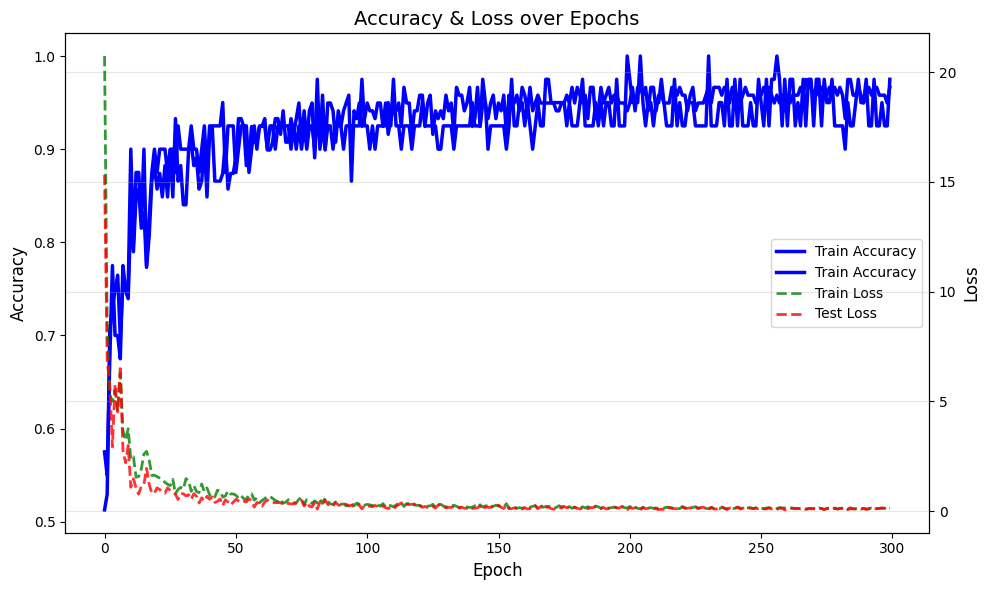

In [27]:
fig, ax1 = plt.subplots(figsize = (10, 6))

# Accuracy (왼쪽 축)
ax1.plot(train_score,
         color = 'blue',
         linewidth = 2.5,
         label = 'Train Accuracy')

ax1.plot(test_score,
         color = 'blue',
         linewidth = 2.5,
         label = 'Train Accuracy')

ax1.set_xlabel('Epoch', fontsize = 12)
ax1.set_ylabel('Accuracy', fontsize = 12)
ax1.tick_params(axis = 'y')

# Loss (오른쪽 축)
ax2 = ax1.twinx()

ax2.plot(train_loss,
         color = 'green',
         linestyle = '--',
         linewidth = 2,
         alpha = 0.8,
         label = 'Train Loss')

ax2.plot(test_loss,
         color = 'red',
         linestyle = '--',
         linewidth = 2,
         alpha = 0.8,
         label = 'Test Loss')

ax2.set_ylabel('Loss', fontsize = 12)

# 범례를 통합한다.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Accuracy & Loss over Epochs', fontsize = 14)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 조기 종료(Early Stopping) 지점을 찾아보자.
# 'test_loss'가 가장 낮은 'epoch' 또는 'patience' 횟수만큼 연속적으로 증가하면 멈춘다.
# minL(test) : 'test_loss'가 더 이상 감소하지 않는 지점을 찾아낸다.

In [28]:
patience = 10
best_loss = float('inf')
patience_counter = 0
early_stop_epoch = 0

train_score_early = []
test_score_early = []
train_loss_early = []
test_loss_early = []

sc_hinge_test_early = SGDClassifier(loss = 'hinge', max_iter = 1, tol = None, random_state = 42)

for epoch in range(300) :
  sc_hinge_test_early.partial_fit(train_scaled, train_target, classes = classes)

  # acurracy 저장
  train_score_early.append(sc_hinge_test_early.score(train_scaled, train_target))
  test_score_early.append(sc_hinge_test_early.score(test_scaled, test_target))

  # loss 계산
  train_decision = sc_hinge_test.decision_function(train_scaled)
  test_decision = sc_hinge_test.decision_function(test_scaled)

  current_test_loss = hinge_loss(test_target, test_decision)
  train_loss_early.append(hinge_loss(train_target, train_decision))
  test_loss_early.append(current_test_loss)

  # Early Stopping 체크
  if current_test_loss < best_loss :
    best_loss = current_test_loss
    patience_counter = 0
    early_stop_epoch = epoch

  else :
    patience_counter += 1

  if patience_counter >= patience :
    print(f"Early Stopping at epoch {epoch}")
    break

Early Stopping at epoch 10


/tmp/ipython-input-161/3012774906.py:26: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'center right')


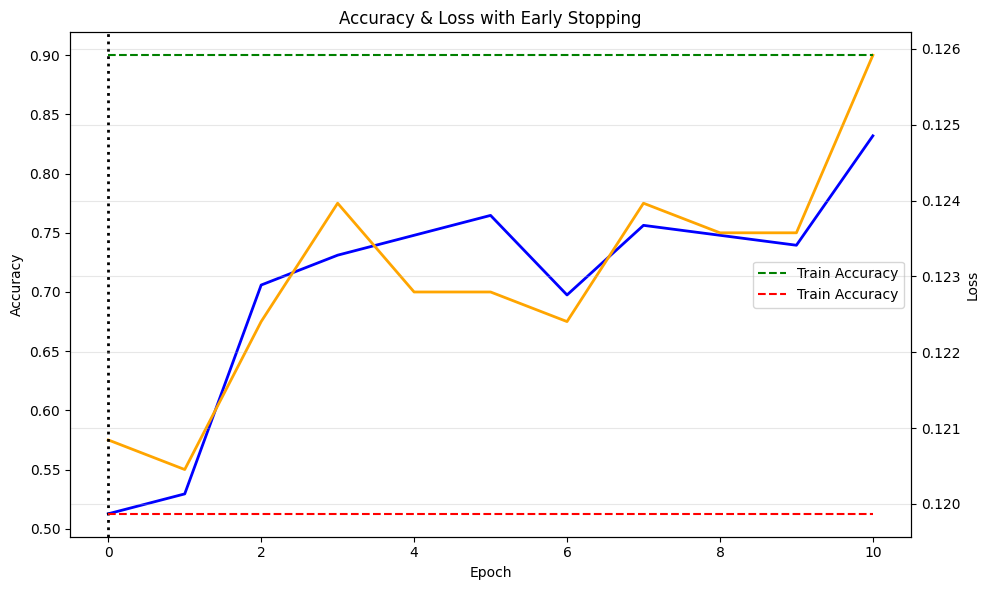

In [29]:
fig, ax1 = plt.subplots(figsize = (10, 6))

# Accuracy
ax1.plot(train_score_early, color = 'blue', linewidth = 2, label = 'Train Acc')
ax1.plot(test_score_early, color = 'orange', linewidth = 2, label = 'Test Acc')

# Early Stopping (세로선)
ax1.axvline(x = early_stop_epoch,
            color = 'black',
            linestyle = ':',
            linewidth = 2,
            label = 'Early Stop')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

# Loss
ax2 = ax1.twinx()
ax2.plot(train_loss_early, color = 'green', linestyle = '--', label = 'Train Loss')
ax2.plot(test_loss_early, color = 'red', linestyle = '--', label = 'Test Loss')
ax2.set_ylabel('Loss')

# 범례를 통합한다.
lines1, lines2 = ax1.get_legend_handles_labels()
lines1, lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'center right')

plt.title('Accuracy & Loss with Early Stopping')
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()